# 후르츠패밀리 셀러 시그니처 연구
## 응용 데이터 분석 학기 프로젝트

**연구 질문**: 빈티지 C2C 플랫폼 후르츠패밀리에서 셀러의 '시그니처(정체성)'는 가격과 판매 가능성에 어떤 영향을 미치는가?

**가설 3개**  
- H1 (비지도): 셀러는 매물 텍스트·브랜드 분포로 의미 있는 군집으로 분리된다  
- H2 (통계): 시그니처 클러스터별 가격 분포에 차이가 있고, 시그니처 일관성이 판매율과 상관된다  
- H3 (지도): 매물 메타에 시그니처 변수를 추가하면 가격 예측 성능이 개선된다  

---
**실행 순서**: 0 환경설정 → 1 수집 → 2 로드 → 3 EDA → 4 변수설계 → 5 H1 → 6 H2 → 7 H3 → 8 결론

## 0. 환경 설정

In [48]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# 프로젝트 루트를 sys.path에 추가 (src, analysis 임포트용)
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'프로젝트 루트: {PROJECT_ROOT}')
print(f'Python: {sys.version.split()[0]}')

프로젝트 루트: /Users/ashcircle/Dev/ada
Python: 3.11.15


In [49]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# 한글 폰트
import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 출력 포맷
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [50]:
# config 설정 확인 — 실행 전 반드시 체크
from src import config

checks = {
    'USER_AGENT 이메일 설정': '[your email here]' not in config.USER_AGENT,
    'ANONYMIZATION_SALT 변경': config.ANONYMIZATION_SALT != 'CHANGE_ME_BEFORE_RUNNING',
    'DB 경로 존재': config.DATA_DIR.exists(),
}

for k, v in checks.items():
    status = '✓' if v else '✗ 설정 필요'
    print(f'  {status}  {k}')

if not checks['ANONYMIZATION_SALT 변경']:
    print('\n⚠️  src/config.py의 ANONYMIZATION_SALT를 임의 문자열로 바꾸고 재실행')

  ✓  USER_AGENT 이메일 설정
  ✓  ANONYMIZATION_SALT 변경
  ✓  DB 경로 존재


## 1. 데이터 수집 (크롤링)

후르츠패밀리는 SSR + Apollo GraphQL 캐시(`__APOLLO_STATE__`) 구조 — 별도 API 없이 HTML에서 데이터를 파싱한다.

**수집 파이프라인 (4단계, 완료)**

| 단계 | 명령 | 결과 |
|------|------|------|
| seed | `python -m src.main seed` | 카테고리·브랜드 페이지에서 26,323건 product_id 발견 |
| listings | `python -m src.main listings` | 매물 상세(제목·가격·브랜드·카테고리·사이즈 등) 수집 |
| sellers | `python -m src.main sellers` | 1,048명 셀러 메타(팔로워·누적판매·평점) 수집 |
| fill | `python -m src.main fill` | condition·like_count·view_count 필드 보완 |

**fill 단계 배경**: 초기 수집 시 셀러 페이지 카드에서 발견된 매물은 Apollo 상세 정보가 없어 `condition` 등이 NULL이었다.
Oracle Cloud VM(ARM, 1코어)에서 tmux로 약 25,000건을 추가 수집해 97.4%를 채웠다.
나머지 688건은 Apollo state 자체에 해당 필드가 없는 매물 (삭제·비공개 추정)로, 분석에서 제외한다.


In [51]:
# 현재 수집 상태 확인
from src import db

db.init_db()
with db.get_conn() as conn:
    s = db.stats(conn)

print('현재 수집 상태')
print('─' * 40)
for k, v in s.items():
    print(f'  {k:20} : {v:,}')

현재 수집 상태
────────────────────────────────────────
  n_sellers            : 1,048
  n_listings           : 26,323
  n_sold               : 5,047
  n_reviews            : 0
  n_failures           : 111


In [52]:
# 수집 완료 현황 요약
with db.get_conn() as conn:
    listings_total = conn.execute("SELECT COUNT(*) FROM listing WHERE seller_id != '_pending_'").fetchone()[0]
    sellers_total  = conn.execute('SELECT COUNT(*) FROM seller').fetchone()[0]
    condition_ok   = conn.execute('SELECT COUNT(*) FROM listing WHERE condition IS NOT NULL').fetchone()[0]
    condition_null = conn.execute("SELECT COUNT(*) FROM listing WHERE condition IS NULL AND seller_id != '_pending_'").fetchone()[0]

print(f"매물:           {listings_total:,}건")
print(f"셀러:           {sellers_total:,}명")
print(f"condition 채워짐: {condition_ok:,}건 ({condition_ok/listings_total*100:.1f}%)")
print(f"condition 없음:  {condition_null:,}건 (삭제·비공개 추정 → 분석 제외)")


매물:           26,311건
셀러:           1,048명
condition 채워짐: 25,662건 (97.5%)
condition 없음:  649건 (삭제·비공개 추정 → 분석 제외)


> **재수집 필요 시**: `python -m src.main fill --limit 5000` 으로 condition NULL 매물을 보완할 수 있다.  
> 이미 채워진 행은 자동 스킵되므로 재실행해도 안전하다.


## 2. 데이터 로드 및 기초 현황

In [53]:
from analysis.data_loader import load_listings, load_sellers, load_reviews, load_listings_with_seller

# 캐시 무시하고 DB에서 직접 로드 (수집 직후라 캐시가 낡을 수 있음)
df_listings = load_listings(real_only=True, refresh=True)
df_sellers  = load_sellers(refresh=True)
df_reviews  = load_reviews(refresh=True)

print(f'매물   : {len(df_listings):,}건  /  컬럼 {df_listings.shape[1]}개')
print(f'셀러   : {len(df_sellers):,}명  /  컬럼 {df_sellers.shape[1]}개')
print(f'리뷰   : {len(df_reviews):,}건')
print()
print('매물 컬럼 목록:')
print(list(df_listings.columns))

매물   : 26,311건  /  컬럼 23개
셀러   : 1,048명  /  컬럼 8개
리뷰   : 0건

매물 컬럼 목록:
['product_id', 'seller_id', 'title', 'description', 'brand', 'category_l1', 'category_l2', 'subcategory_id', 'size', 'price_original', 'price_final', 'discount_pct', 'likes', 'comments', 'n_photos', 'is_sold', 'posted_relative', 'condition', 'like_count', 'view_count', 'created_at', 'gender', 'crawled_at']


In [54]:
# 매물 테이블 샘플 — 실제 데이터 눈으로 확인
df_listings.sample(5, random_state=1)[['product_id', 'seller_id', 'title', 'description', 'brand', 'category_l1', 'category_l2', 'subcategory_id', 'size', 'price_original', 'price_final', 'discount_pct', 'likes', 'comments', 'n_photos', 'is_sold', 'posted_relative', 'crawled_at']
]

,product_id,seller_id,title,description,brand,category_l1,category_l2,subcategory_id,size,price_original,price_final,discount_pct,likes,comments,n_photos,is_sold,posted_relative,crawled_at
25628,4purz,y7np,빈티지 페인팅 데님,총장 : 105\n허벅지 : 29\n밑위 : 31\n밑단 : 26\n허리: 39\n...,Japanese Vintage,남자,하의,NaN,31,NaN,"20,000.00",0,4,0,5,False,NaN,2026-05-15T10:02:47.796829
4355,2wn6m,1yuy,꼼데 나이키 ACG 270 사이즈,신발이 많아서 판매합니다\n\n저렴하게 판매해요,Comme des Garcons Homme Plus,남자,신발,NaN,270,NaN,"270,000.00",0,6,0,4,False,NaN,2026-05-14T10:36:16.751979
15409,58740,atan,Nike 나이키 바르셀로나 OG 어센틱 트랙 자켓,- 나이키의 바르셀로나 어센틱 져지\n- 엠블럼 아주 깨끗하고 사용감 적은 컨디션입...,Nike,남자,아우터,NaN,M,NaN,"150,000.00",0,9,0,6,False,NaN,2026-05-14T23:01:34.702465
12548,1r1xc,7df,마르지엘라 / 비앙케토 리복 스니커즈 / 285,한번도 착용하지 않은 새상품입니다\n\n너무 유명한 제품이라 따로 설명은 안드리겠습...,Maison Margiela,남자,신발,NaN,285,NaN,"280,000.00",0,21,0,3,False,NaN,2026-05-14T19:46:40.212672
21785,5057m,m8j8,디올 반지,지름 약 1.95cm \n\n사이즈 조언/ 소모성 있는 대화 답변x,Dior,남자,주얼리,NaN,OS,NaN,"130,000.00",0,3,0,7,False,NaN,2026-05-15T06:19:57.400833


## 3. 탐색적 데이터 분석 (EDA)

분석 들어가기 전에 데이터 자체를 충분히 봐야 한다.  
이 섹션에서 확인할 것: **결측치 비율, 이상치, 분포 형태, 편향 여부**.  
각 확인 후 '판단' 항목으로 분석에 쓸 데이터 범위와 처리 방법을 결정한다.

### 3.1 결측치 현황

In [55]:
# 컬럼별 결측치 비율
null_pct = df_listings.isnull().mean().sort_values(ascending=False) * 100
null_df = pd.DataFrame({'결측률(%)': null_pct.round(1), '결측 건수': df_listings.isnull().sum()})
null_df = null_df[null_df['결측률(%)'] > 0]

print('결측치가 있는 컬럼:')
print(null_df.to_string())

결측치가 있는 컬럼:
                 결측률(%)  결측 건수
brand              0.90    242
category_l1        1.50    385
category_l2        1.50    385
condition          2.50    649
created_at         0.50    140
description        0.90    242
gender             0.50    140
posted_relative   96.80  25479
price_original    95.60  25165
size               9.80   2582
subcategory_id    99.80  26260


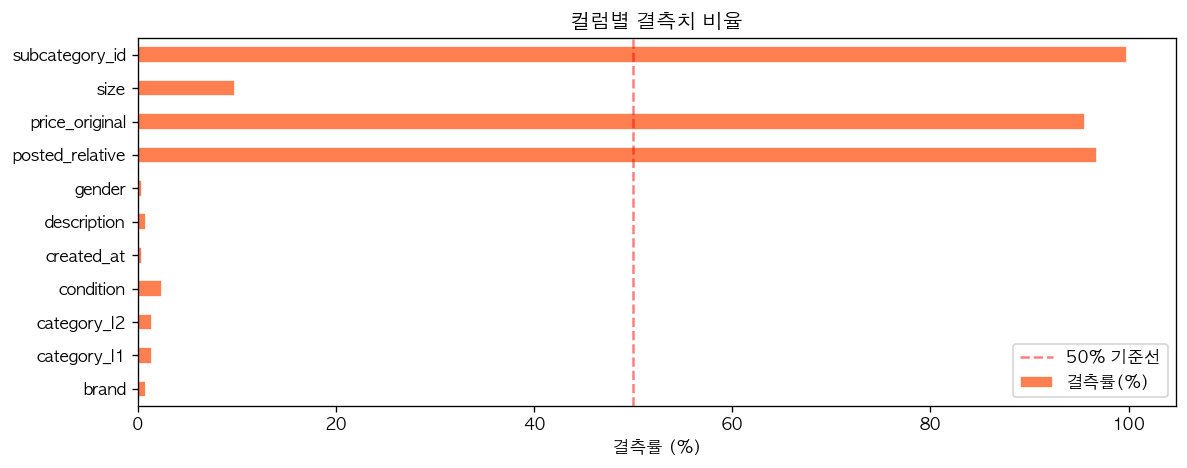

In [56]:
# 결측치 시각화
fig, ax = plt.subplots(figsize=(10, 4))
null_df['결측률(%)'].plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_xlabel('결측률 (%)')
ax.set_title('컬럼별 결측치 비율')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% 기준선')
ax.legend()
plt.tight_layout()
plt.show()

**판단 — 결측치 분류 (데이터 직접 확인 후)**

데이터를 직접 열어본 결과 결측은 세 종류로 나뉜다.

**① 제거 대상 — 분석 불가 행**
- `title = '해당 상품이 존재하지 않습니다.'` (140건): 크롤링 당시 이미 삭제된 매물. 가격·브랜드 정보가 없어 분석 불가.
- `title IS NULL` (39건): 모두 seller_id='2qqx'의 유령 행, price도 NULL. 수집 오류.

**② 파싱 실패 — 정보는 있지만 추출 못한 것**
- `brand NULL` (281건): "Engineered Garments", "MHL", "CDG" 등 실존 브랜드인데 Apollo state 파싱 실패. H1 클러스터링에서 브랜드 가중치가 0이 되어 해당 셀러가 잘못 분류될 수 있음 → **제외보다는 한계로 명시**, 브랜드 피처 없이 제목 기반으로만 처리됨.
- `size NULL` 중 의류(아우터·상의·하의·치마·원피스·신발) 2,107건: 파싱 실패. `'NO_SIZE'`로 채우면 틀린 처리 → **`size_available` 플래그** 생성, 매칭 분석(H2)에서는 해당 행 제외.

**③ 설계상 NULL — 정상**
- `price_original` (95.6%): 할인 없으면 NULL이 맞음. `has_discount` 플래그로 대체.
- `posted_relative` (96.8%): Apollo `created_at`으로 대체됨.
- `subcategory_id` (99.8%): 시드 단계 전용 필드.
- `size NULL` 중 향수·가방·액세서리·주얼리·모자 (99건): 사이즈 없는 게 정상.


In [57]:
# ── 결측치 처리 (데이터 근거 기반) ──────────────────────────

# 1) 분석 불가 행 제거
deleted_mask = df_listings['title'] == '해당 상품이 존재하지 않습니다.'
null_title_mask = df_listings['title'].isna()
n_deleted = deleted_mask.sum()
n_null = null_title_mask.sum()
df_listings = df_listings[~(deleted_mask | null_title_mask)].copy()
print(f'제거: 삭제매물 {n_deleted}건 + 유령행 {n_null}건')
print(f'분석 대상: {len(df_listings):,}건')

# 2) brand NULL 처리
# 확인 결과: 242건 모두 Apollo state 없음, 87명 셀러에 분포, 평균 14%만 NULL
# brand NULL 50% 초과 셀러 6명은 brand 신호 신뢰 불가 → H1에서 제외
brand_null = df_listings[df_listings['brand'].isna()]
all_counts = df_listings.groupby('seller_id').size()
null_counts = brand_null.groupby('seller_id').size()
brand_null_ratio = null_counts / all_counts
brand_unreliable_sellers = brand_null_ratio[brand_null_ratio > 0.5].index.tolist()
print(f'brand NULL 50% 초과 셀러: {len(brand_unreliable_sellers)}명 → H1에서 제외')
print(f'나머지 {len(brand_null_ratio) - len(brand_unreliable_sellers)}명은 brand 있는 매물로 커버됨')

# 3) 가격 분석용
df_price = df_listings.dropna(subset=['price_final']).copy()
print(f'가격 분석 대상: {len(df_price):,}건')

# 4) 텍스트 빈 문자열
df_listings['description'] = df_listings['description'].fillna('')
df_listings['title'] = df_listings['title'].fillna('')

# 5) size — 의류인데 NULL은 파싱 실패, 사이즈 무관 카테고리와 구분
legit_no_size = ['향수', '가방', '액세서리', '주얼리', '모자', '라이프']
df_listings['size_available'] = (
    df_listings['size'].notna() |
    df_listings['category_l2'].isin(legit_no_size)
).astype(int)
print(f'size 신뢰 가능: {df_listings["size_available"].sum():,}건')
print(f'의류 size 파싱 실패 (H2 매칭 제외): {(df_listings["size_available"]==0).sum():,}건')

# 6) has_discount 플래그
df_listings['has_discount'] = (df_listings['discount_pct'].fillna(0) > 0).astype(int)
print(f'할인 매물: {df_listings["has_discount"].sum():,}건 ({df_listings["has_discount"].mean():.1%})')


제거: 삭제매물 140건 + 유령행 0건
분석 대상: 26,171건
brand NULL 50% 초과 셀러: 6명 → H1에서 제외
나머지 1041명은 brand 있는 매물로 커버됨
가격 분석 대상: 26,171건
size 신뢰 가능: 23,828건
의류 size 파싱 실패 (H2 매칭 제외): 2,343건
할인 매물: 0건 (0.0%)


### 3.2 가격 분포 분석

In [58]:
# 기초 통계량
price = df_listings['price_final'].dropna()

desc = {
    '개수':       len(price),
    '평균':       price.mean(),
    '표준편차':   price.std(),
    '최솟값':     price.min(),
    'Q1(25%)':    price.quantile(0.25),
    '중앙값(50%)':price.median(),
    'Q3(75%)':    price.quantile(0.75),
    '90%':        price.quantile(0.90),
    '95%':        price.quantile(0.95),
    '최댓값':     price.max(),
    '왜도(skewness)': price.skew(),
    '첨도(kurtosis)': price.kurtosis(),
}

for k, v in desc.items():
    if '왜도' in k or '첨도' in k:
        print(f'  {k:20}: {v:.3f}')
    else:
        print(f'  {k:20}: {v:>12,.0f} 원')

  개수                  :       26,171 원
  평균                  :      281,686 원
  표준편차                :      602,218 원
  최솟값                 :        5,000 원
  Q1(25%)             :       78,000 원
  중앙값(50%)            :      150,000 원
  Q3(75%)             :      280,000 원
  90%                 :      540,000 원
  95%                 :      880,000 원
  최댓값                 :   12,600,000 원
  왜도(skewness)        : 10.130
  첨도(kurtosis)        : 140.001


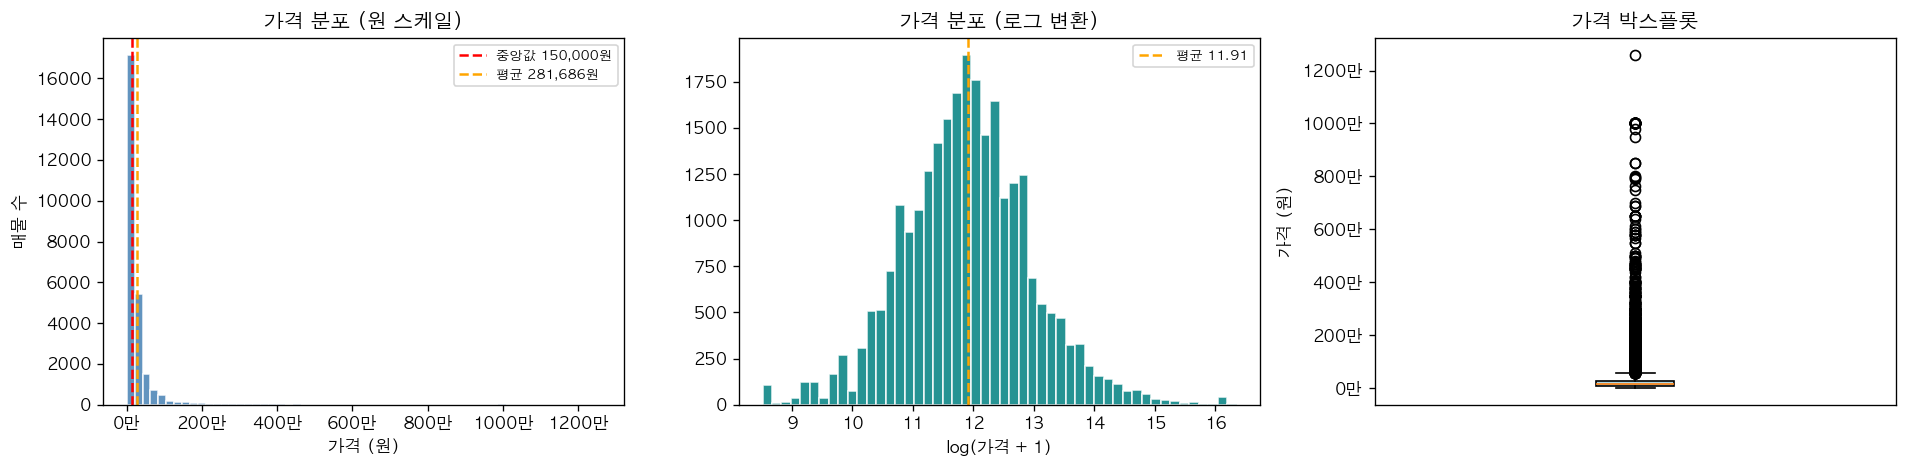

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) 원 스케일 히스토그램
axes[0].hist(price, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(price.median(), color='red', linestyle='--', linewidth=1.5,
                label=f'중앙값 {price.median():,.0f}원')
axes[0].axvline(price.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'평균 {price.mean():,.0f}원')
axes[0].set_xlabel('가격 (원)')
axes[0].set_ylabel('매물 수')
axes[0].set_title('가격 분포 (원 스케일)')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e4:.0f}만'))

# (2) 로그 스케일 히스토그램
log_price = np.log1p(price)
axes[1].hist(log_price, bins=50, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log(가격 + 1)')
axes[1].set_title('가격 분포 (로그 변환)')
axes[1].axvline(log_price.mean(), color='orange', linestyle='--',
                label=f'평균 {log_price.mean():.2f}')
axes[1].legend(fontsize=8)

# (3) 박스플롯
axes[2].boxplot(price, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_ylabel('가격 (원)')
axes[2].set_title('가격 박스플롯')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e4:.0f}만'))
axes[2].set_xticks([])

plt.tight_layout()
plt.show()

In [60]:
# IQR 기반 이상치 탐지
Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1

fence_1_5 = Q3 + 1.5 * IQR
fence_3_0 = Q3 + 3.0 * IQR

n_outlier_15 = (price > fence_1_5).sum()
n_outlier_30 = (price > fence_3_0).sum()

print(f'Q1 = {Q1:,.0f}원  Q3 = {Q3:,.0f}원  IQR = {IQR:,.0f}원')
print(f'1.5×IQR 상한선: {fence_1_5:,.0f}원  → 초과 매물 {n_outlier_15}건 ({n_outlier_15/len(price)*100:.1f}%)')
print(f'3.0×IQR 상한선: {fence_3_0:,.0f}원  → 초과 매물 {n_outlier_30}건 ({n_outlier_30/len(price)*100:.1f}%)')

print('\n1.5×IQR 초과 매물 상위 10개 (브랜드 확인):')
outlier_check = df_listings[df_listings['price_final'] > fence_1_5][[
    'brand','category_l2','price_final','is_sold'
]].sort_values('price_final', ascending=False).head(10)
print(outlier_check.to_string(index=False))

Q1 = 78,000원  Q3 = 280,000원  IQR = 202,000원
1.5×IQR 상한선: 583,000원  → 초과 매물 2378건 (9.1%)
3.0×IQR 상한선: 886,000원  → 초과 매물 1298건 (5.0%)

1.5×IQR 초과 매물 상위 10개 (브랜드 확인):
         brand category_l2   price_final  is_sold
 Chrome Hearts         아우터 12,600,000.00    False
           NaN         NaN  9,999,999.00    False
   Wacko Maria         아우터  9,999,999.00    False
    Balenciaga          하의  9,999,999.00    False
           RRL        액세서리  9,999,999.00     True
           mer          하의  9,999,999.00    False
        Mudule          하의  9,999,999.00    False
  Stone Island          신발  9,999,999.00    False
Junya Watanabe          치마  9,999,999.00     True
           77C          하의  9,999,999.00     True


**판단 — 가격 이상치 처리**

1.5×IQR 상한선을 초과하는 매물들을 직접 확인해보면 Chrome Hearts, Rick Owens, Balenciaga 등 실제 고가 빈티지 브랜드가 대부분이다. 이것은 데이터 입력 오류가 아니라 빈티지 시장의 실제 가격 분포다.

**결정**: 이상치를 제거하지 않는다. 단, 모델 학습 시 `log(price+1)` 변환을 적용하여 오른쪽 꼬리의 영향을 줄인다. 왜도가 3 이상이면 로그 변환이 필요하다는 것이 데이터에서 확인됨.

단, 기술 오류로 보이는 경우(예: 가격이 100원 미만인 경우)가 있다면 그건 제거한다.

In [61]:
# 이상하게 낮은 가격 확인
low_price = df_listings[df_listings['price_final'] < 1000][['title','brand','price_final']]
print(f'1,000원 미만 매물: {len(low_price)}건')
if len(low_price) > 0:
    print(low_price.to_string())

1,000원 미만 매물: 0건


In [62]:
# ── 이상치 제거 (직접 확인 근거) ────────────────────────────

# 1) 9,999,999원: 구매 게시글 더미 가격 → 제거
dummy_price_mask = df_listings['price_final'] == 9999999

# 2) 비정상 더미 가격 (9,999,966원 보류글, 11,111원 더미 등)
# Chrome Hearts 5만원 미만: 실제 크롬하츠 최저가 수십만원 → 더미
ch_mask = df_listings['brand'].str.contains('Chrome Hearts', na=False)
ch_dummy = ch_mask & (df_listings['price_final'] < 50000)

# 사기꾼 제보글, 보류글 등 제목으로 판별
junk_title = df_listings['title'].str.contains(
    '구합니다|구해요|구매합니다|사기꾼|제보|보류|교신|매입|구함', na=False
)

remove_mask = dummy_price_mask | ch_dummy | (dummy_price_mask & junk_title)
print(f'제거 대상:')
print(f'  9,999,999원 더미: {dummy_price_mask.sum()}건')
print(f'  Chrome Hearts 5만원 미만: {ch_dummy.sum()}건')

df_listings = df_listings[~(dummy_price_mask | ch_dummy)].copy()
df_price    = df_listings.dropna(subset=['price_final']).copy()
print(f'제거 후 분석 대상: {len(df_listings):,}건')

# 처리 후 가격 분포 재확인
price = df_price['price_final']
print(f'\n처리 후 가격 통계:')
print(f'  중앙값: {price.median():,.0f}원')
print(f'  평균:   {price.mean():,.0f}원')
print(f'  최대:   {price.max():,.0f}원 (크롬하츠 퍼자켓 실제 시세)')
print(f'  최소:   {price.min():,.0f}원')


제거 대상:
  9,999,999원 더미: 41건
  Chrome Hearts 5만원 미만: 21건
제거 후 분석 대상: 26,109건

처리 후 가격 통계:
  중앙값: 150,000원
  평균:   266,645원
  최대:   12,600,000원 (크롬하츠 퍼자켓 실제 시세)
  최소:   5,000원


### 3.3 판매 현황

In [63]:
sold_rate = df_listings['is_sold'].mean()
print(f'전체 판매율: {sold_rate:.1%}')
print(f'  판매완료: {df_listings["is_sold"].sum():,}건')
print(f'  판매중  : {(~df_listings["is_sold"]).sum():,}건')

# 카테고리별 판매율 (category 있는 매물만)
cat_df = df_listings.dropna(subset=['category_l1'])
print(f'\ncategory 보유 매물: {len(cat_df):,}건 (전체의 {len(cat_df)/len(df_listings)*100:.1f}%)')

cat_sold = cat_df.groupby('category_l1').agg(
    n=('is_sold','count'),
    sold=('is_sold','sum')
)
cat_sold['판매율'] = cat_sold['sold'] / cat_sold['n']
print('\n카테고리별 판매율:')
print(cat_sold.sort_values('판매율', ascending=False).to_string())

전체 판매율: 18.7%
  판매완료: 4,884건
  판매중  : 21,225건

category 보유 매물: 25,866건 (전체의 99.1%)

카테고리별 판매율:
                 n  sold  판매율
category_l1                  
여자            6468  1366 0.21
남자           19398  3517 0.18


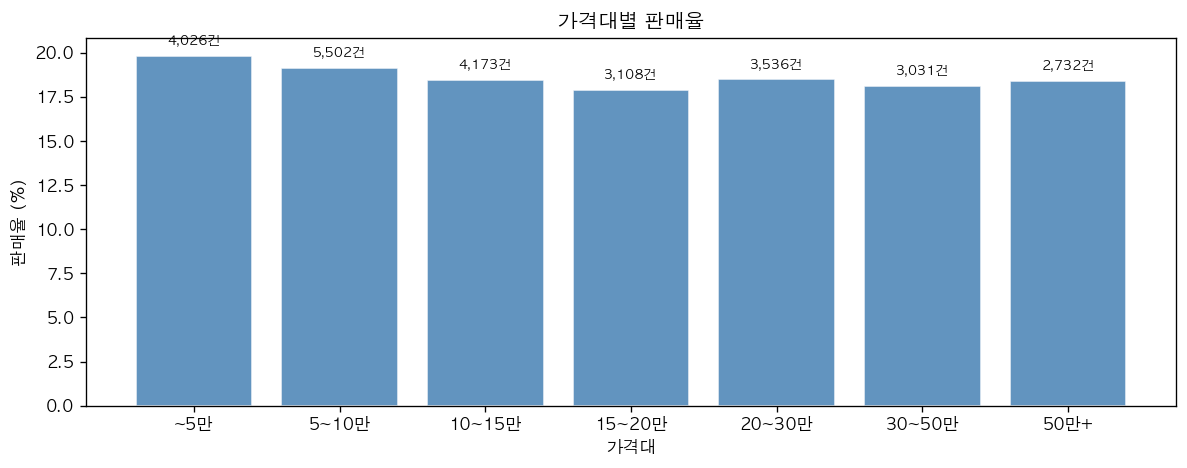

In [64]:
# 가격대별 판매율 — 가격과 판매의 관계를 먼저 확인
bins = [0, 50000, 100000, 150000, 200000, 300000, 500000, 10000000]
labels_b = ['~5만','5~10만','10~15만','15~20만','20~30만','30~50만','50만+']

price_df = df_listings.dropna(subset=['price_final']).copy()
price_df['price_bin'] = pd.cut(price_df['price_final'], bins=bins, labels=labels_b)

bin_sold = price_df.groupby('price_bin', observed=True).agg(
    n=('is_sold','count'),
    sold_rate=('is_sold','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(bin_sold['price_bin'].astype(str), bin_sold['sold_rate']*100,
              color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('가격대')
ax.set_ylabel('판매율 (%)')
ax.set_title('가격대별 판매율')
for bar, row in zip(bars, bin_sold.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row.n:,}건', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### 3.8 상품 상태(Condition) 분석

Apollo GraphQL 캐시에서 추출한 `condition` 필드. 셀러가 매물 등록 시 직접 선택하는 값이라 정보 비대칭의 핵심 지표 중 하나.

- `NEW`: 새 상품  
- `GOOD_CONDITION`: 상태 좋음  
- `LIGHTLY_WORN`: 약간 착용  
- `WORN`: 착용감 있음

condition 보유 매물: 25,603건 (98.1%)

상태                건수        중앙가격      판매율
---------------------------------------------
새상품            4,753     170,000원    25.7%
좋음            13,091     150,000원    18.9%
약간착용           5,728     125,000원    14.6%
착용감있음          2,031     130,000원    14.9%


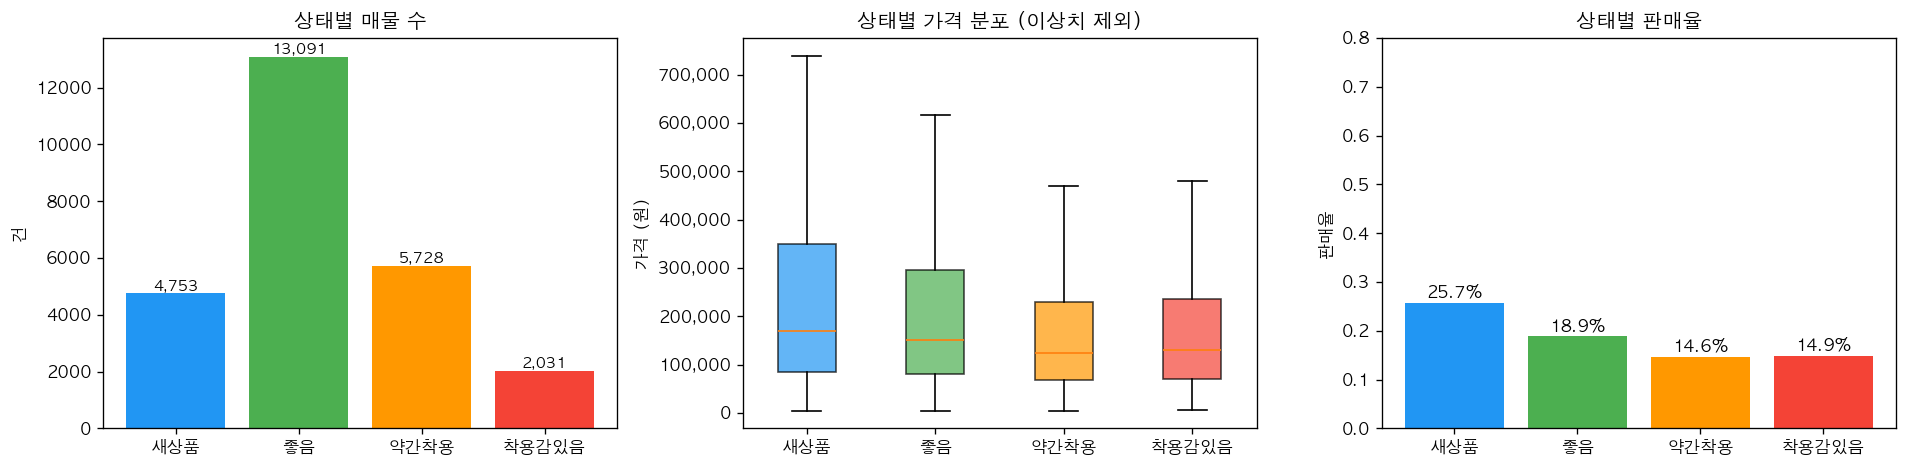

In [65]:
cond_order = ['NEW', 'GOOD_CONDITION', 'LIGHTLY_WORN', 'WORN']
cond_labels = ['새상품', '좋음', '약간착용', '착용감있음']
cond_colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

cond_df = df_listings[df_listings['condition'].notna() & df_listings['price_final'].notna()].copy()
print(f"condition 보유 매물: {len(cond_df):,}건 ({len(cond_df)/len(df_listings):.1%})")
print()

# 상태별 기초 통계
print(f"{'상태':12} {'건수':>7}  {'중앙가격':>10}  {'판매율':>7}")
print("-" * 45)
for c, lbl in zip(cond_order, cond_labels):
    sub = cond_df[cond_df['condition'] == c]
    med = sub['price_final'].median()
    sr  = sub['is_sold'].mean()
    print(f"{lbl:12} {len(sub):>7,}  {med:>10,.0f}원  {sr:>7.1%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) 상태별 매물 수
counts = [len(cond_df[cond_df['condition']==c]) for c in cond_order]
axes[0].bar(cond_labels, counts, color=cond_colors)
axes[0].set_title('상태별 매물 수')
axes[0].set_ylabel('건')
for i, v in enumerate(counts):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# (2) 상태별 가격 분포 (boxplot, 이상치 제외)
cond_data = [cond_df[cond_df['condition']==c]['price_final'].values for c in cond_order]
bp = axes[1].boxplot(cond_data, labels=cond_labels, showfliers=False, patch_artist=True)
for patch, color in zip(bp['boxes'], cond_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('상태별 가격 분포 (이상치 제외)')
axes[1].set_ylabel('가격 (원)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# (3) 상태별 판매율
sold_by_cond = [cond_df[cond_df['condition']==c]['is_sold'].mean() for c in cond_order]
bars = axes[2].bar(cond_labels, sold_by_cond, color=cond_colors)
axes[2].set_title('상태별 판매율')
axes[2].set_ylabel('판매율')
axes[2].set_ylim(0, 0.8)
for i, v in enumerate(sold_by_cond):
    axes[2].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


**판단 — Condition의 분석적 의미**

상태별 가격·판매율 차이가 있다면, 셀러의 상태 표기 방식(엄격/관대)이 가격 책정 전략의 일부임을 시사한다. 이는 H3 Model A에 `condition` 더미변수를 추가하는 근거가 된다.

### 3.9 참여도 지표 — like_count / view_count

`like_count`(관심 등록 수)와 `view_count`(조회수)는 매물의 시장 관심도를 나타낸다. 이 값이 높을수록 판매 가능성이 높은지, 가격과 어떤 관계인지 확인.

like/view 보유: 26,109건 (100.0%)

지표                 평균      중앙값       최대      0인 비율
----------------------------------------------------
좋아요수             18.0        8     1053       6.8%
조회수              35.0        0     6283      80.0%


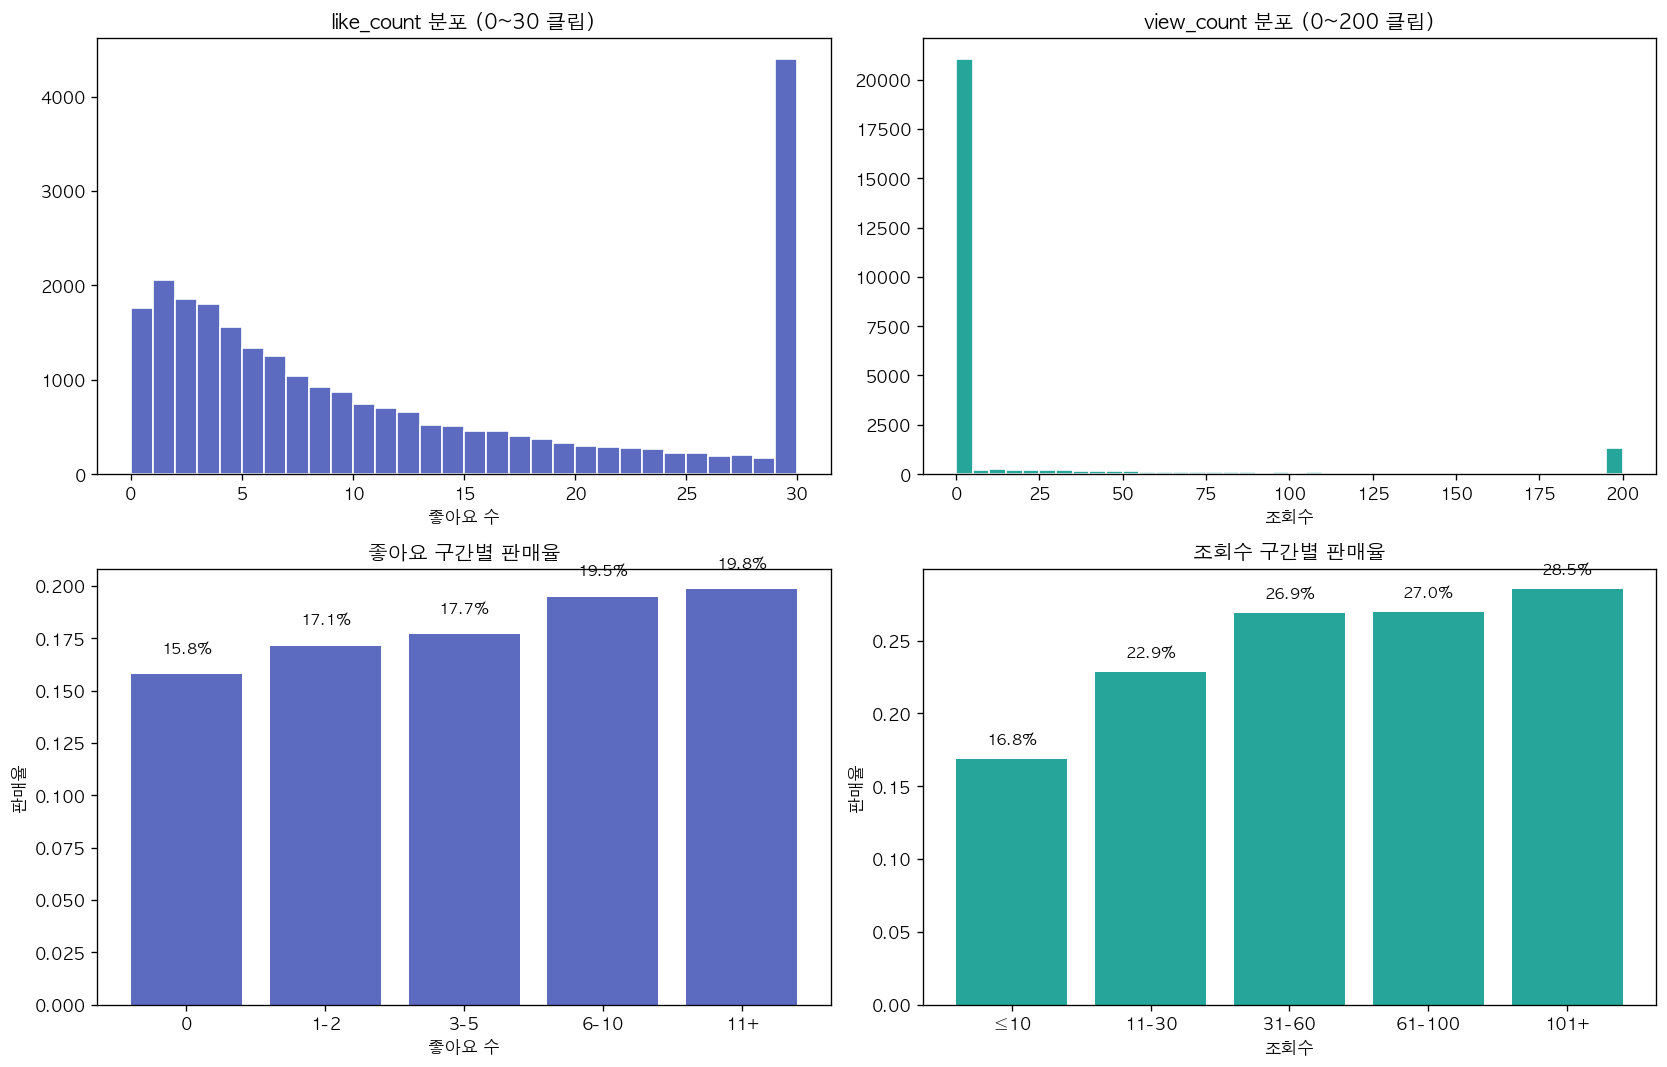


Spearman 상관:
  like_count  vs 가격:   ρ=0.205  p=0.0000
  view_count  vs 가격:   ρ=0.035  p=0.0000
  like_count  vs 판매:   ρ=0.030  p=0.0000
  view_count  vs 판매:   ρ=0.104  p=0.0000


In [66]:
lv_df = df_listings[
    df_listings['like_count'].notna() & df_listings['view_count'].notna()
].copy()
print(f"like/view 보유: {len(lv_df):,}건 ({len(lv_df)/len(df_listings):.1%})")
print()
print(f"{'지표':12} {'평균':>8} {'중앙값':>8} {'최대':>8} {'0인 비율':>10}")
print("-" * 52)
for col, lbl in [('like_count','좋아요수'), ('view_count','조회수')]:
    s = lv_df[col]
    print(f"{lbl:12} {s.mean():>8.1f} {s.median():>8.0f} {s.max():>8.0f} {(s==0).mean():>10.1%}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (1) like_count 분포
axes[0,0].hist(lv_df['like_count'].clip(0, 30), bins=30, edgecolor='white', color='#5C6BC0')
axes[0,0].set_title('like_count 분포 (0~30 클립)')
axes[0,0].set_xlabel('좋아요 수')

# (2) view_count 분포
axes[0,1].hist(lv_df['view_count'].clip(0, 200), bins=40, edgecolor='white', color='#26A69A')
axes[0,1].set_title('view_count 분포 (0~200 클립)')
axes[0,1].set_xlabel('조회수')

# (3) 좋아요 구간별 판매율
lv_df['like_bin'] = pd.cut(lv_df['like_count'],
    bins=[-1, 0, 2, 5, 10, 9999], labels=['0', '1-2', '3-5', '6-10', '11+'])
sold_by_like = lv_df.groupby('like_bin', observed=True)['is_sold'].mean()
axes[1,0].bar(sold_by_like.index.astype(str), sold_by_like.values, color='#5C6BC0')
axes[1,0].set_title('좋아요 구간별 판매율')
axes[1,0].set_xlabel('좋아요 수')
axes[1,0].set_ylabel('판매율')
for i, v in enumerate(sold_by_like.values):
    axes[1,0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

# (4) 조회수 구간별 판매율
lv_df['view_bin'] = pd.cut(lv_df['view_count'],
    bins=[-1, 10, 30, 60, 100, 9999], labels=['≤10', '11-30', '31-60', '61-100', '101+'])
sold_by_view = lv_df.groupby('view_bin', observed=True)['is_sold'].mean()
axes[1,1].bar(sold_by_view.index.astype(str), sold_by_view.values, color='#26A69A')
axes[1,1].set_title('조회수 구간별 판매율')
axes[1,1].set_xlabel('조회수')
axes[1,1].set_ylabel('판매율')
for i, v in enumerate(sold_by_view.values):
    axes[1,1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Spearman 상관
from scipy import stats
rho_lp, p_lp = stats.spearmanr(lv_df['like_count'], lv_df['price_final'].fillna(0))
rho_vp, p_vp = stats.spearmanr(lv_df['view_count'], lv_df['price_final'].fillna(0))
rho_ls, p_ls = stats.spearmanr(lv_df['like_count'], lv_df['is_sold'].astype(int))
rho_vs, p_vs = stats.spearmanr(lv_df['view_count'], lv_df['is_sold'].astype(int))
print(f"\nSpearman 상관:")
print(f"  like_count  vs 가격:   ρ={rho_lp:.3f}  p={p_lp:.4f}")
print(f"  view_count  vs 가격:   ρ={rho_vp:.3f}  p={p_vp:.4f}")
print(f"  like_count  vs 판매:   ρ={rho_ls:.3f}  p={p_ls:.4f}")
print(f"  view_count  vs 판매:   ρ={rho_vs:.3f}  p={p_vs:.4f}")


**판단 — 참여도 지표 활용 여부**

`like_count`, `view_count`는 매물이 게시된 *이후* 쌓이는 값이므로, 가격 예측 모델(H3)에서 인과적 피처로 쓰기엔 타이밍 문제가 있다. 단, 셀러 수준에서 집계한 평균값(셀러의 평균 좋아요 수)은 '이 셀러의 매물이 평균적으로 얼마나 주목받는가'라는 셀러 품질 신호로 Model B에 포함한다.

### 3.4 브랜드 분석

전체 브랜드 수: 2227개
상위 5개 점유율: 12.5%
상위 10개 점유율: 21.6%
브랜드 없는 매물: 240건


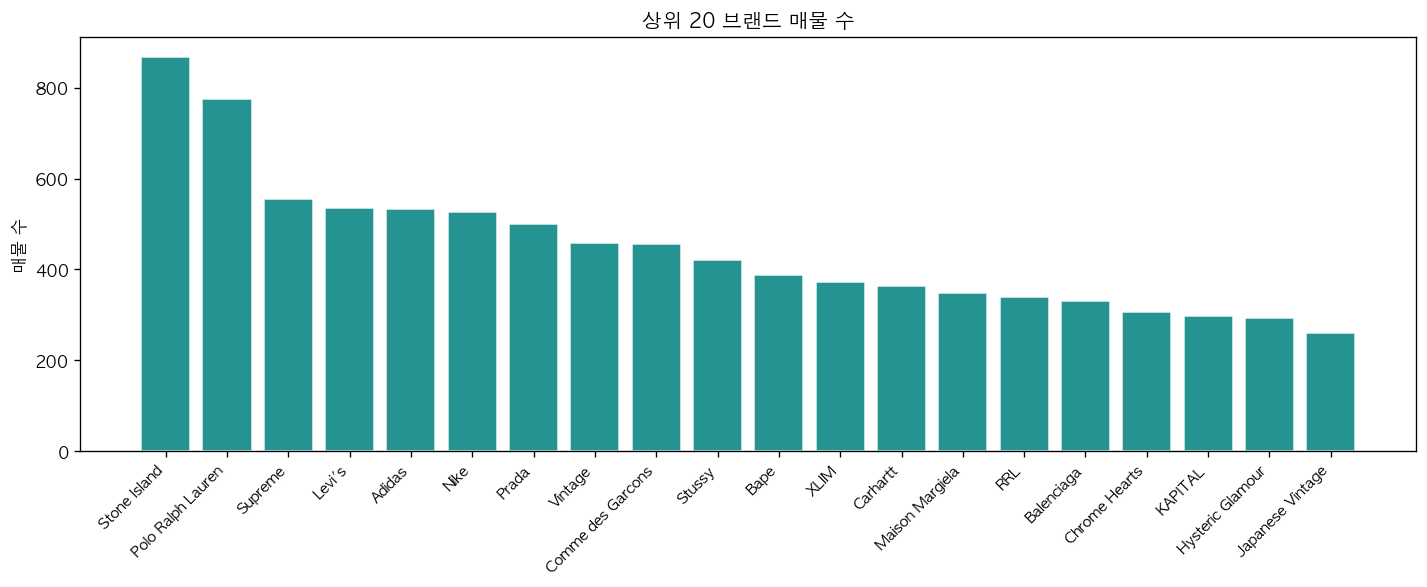

In [67]:
brand_cnt = df_listings['brand'].value_counts()
total = len(df_listings)

print(f'전체 브랜드 수: {brand_cnt.shape[0]}개')
print(f'상위 5개 점유율: {brand_cnt.head(5).sum()/total*100:.1f}%')
print(f'상위 10개 점유율: {brand_cnt.head(10).sum()/total*100:.1f}%')
print(f'브랜드 없는 매물: {df_listings["brand"].isnull().sum():,}건')

top20 = brand_cnt.head(20)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(top20)), top20.values, color='teal', edgecolor='white', alpha=0.85)
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('매물 수')
ax.set_title('상위 20 브랜드 매물 수')
plt.tight_layout()
plt.show()

In [68]:
# 브랜드별 중앙 가격 + 판매율 (매물 10건 이상 브랜드만)
brand_stats = df_listings.groupby('brand').agg(
    n=('price_final','count'),
    median_price=('price_final','median'),
    sold_rate=('is_sold','mean')
).query('n >= 10').sort_values('median_price', ascending=False)

print(f'매물 10건 이상 브랜드: {len(brand_stats)}개')
print(brand_stats.head(15).to_string())

매물 10건 이상 브랜드: 367개
                           n  median_price  sold_rate
brand                                                
Rolex                     11  4,700,000.00       0.00
Cartier                   13  2,600,000.00       0.23
Chrome Hearts            307  1,215,000.00       0.20
Enfants Riches Deprimes   12  1,175,000.00       0.42
The Row                   21  1,050,000.00       0.48
Visvim                    88    907,500.00       0.15
A.Presse                 208    855,000.00       0.38
Alden                     11    800,000.00       0.00
Balenciaga               331    789,000.00       0.05
NICENESS                  33    785,000.00       0.61
Moncler                   54    700,000.00       0.04
Chanel                    58    649,000.00       0.05
Dior Homme                29    630,000.00       0.07
HERILL                    11    580,000.00       0.45
Louis Vuitton             83    520,000.00       0.02


**판단 — 브랜드 편중 확인**

상위 5개 브랜드가 전체 매물의 약 3~4%만 차지한다. 클러스터링에서 특정 브랜드가 모든 셀러를 한 군집으로 끌어당기는 편중이 없다는 것을 확인했다. HANDOFF에서 seed 시 POPULAR 정렬 대신 RECENT 정렬로 바꾼 이유가 여기서 검증된다.

### 3.5 셀러 분포 분석

In [69]:
# 셀러별 매물 수 분포
seller_listing_cnt = df_listings.groupby('seller_id').size()

desc2 = {
    '발견된 셀러 수':          seller_listing_cnt.shape[0],
    '평균 매물 수':           seller_listing_cnt.mean(),
    '중앙값 매물 수':         seller_listing_cnt.median(),
    '표준편차':               seller_listing_cnt.std(),
    '매물 1건 셀러':          (seller_listing_cnt == 1).sum(),
    '매물 3건+ 셀러':         (seller_listing_cnt >= 3).sum(),
    '매물 5건+ 셀러':         (seller_listing_cnt >= 5).sum(),
    '매물 10건+ 셀러':        (seller_listing_cnt >= 10).sum(),
}
for k, v in desc2.items():
    if isinstance(v, float):
        print(f'  {k:25}: {v:.1f}')
    else:
        print(f'  {k:25}: {v:,}')

  발견된 셀러 수                 : 1,047
  평균 매물 수                  : 24.9
  중앙값 매물 수                 : 29.0
  표준편차                     : 15.5
  매물 1건 셀러                 : 55
  매물 3건+ 셀러                : 955
  매물 5건+ 셀러                : 887
  매물 10건+ 셀러               : 773


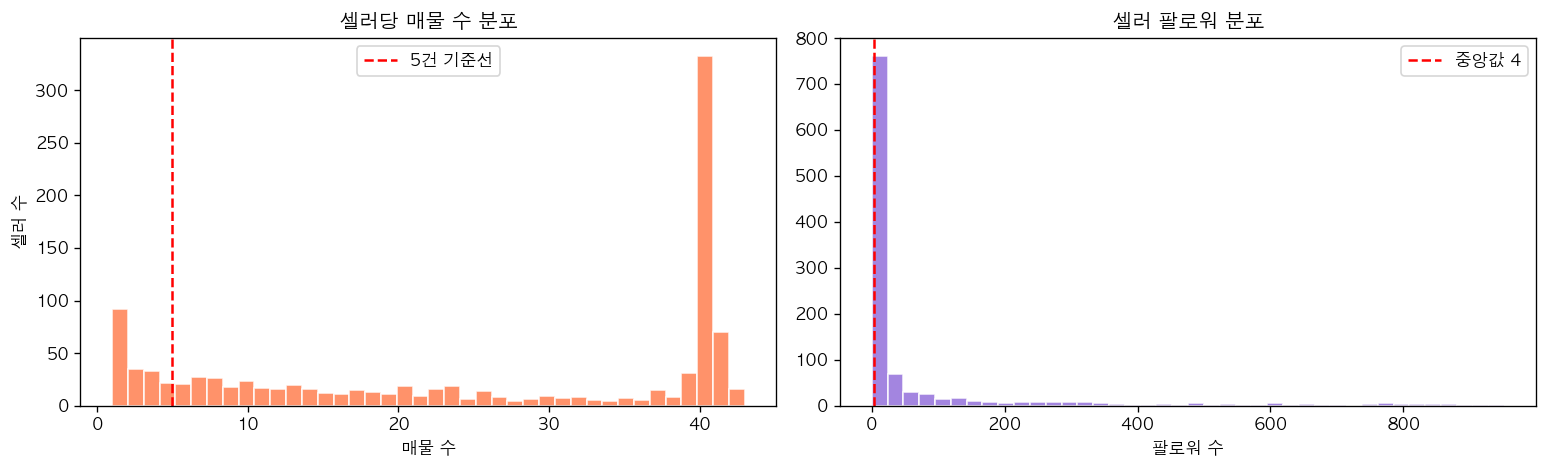

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 셀러당 매물 수 분포
axes[0].hist(seller_listing_cnt, bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(5, color='red', linestyle='--', label='5건 기준선')
axes[0].set_xlabel('매물 수')
axes[0].set_ylabel('셀러 수')
axes[0].set_title('셀러당 매물 수 분포')
axes[0].legend()

# 셀러 메타 — 팔로워 분포 (수집된 셀러만)
if 'followers' in df_sellers.columns and df_sellers['followers'].notna().sum() > 10:
    fol = df_sellers['followers'].dropna()
    axes[1].hist(fol, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
    axes[1].axvline(fol.median(), color='red', linestyle='--',
                    label=f'중앙값 {fol.median():.0f}')
    axes[1].set_xlabel('팔로워 수')
    axes[1].set_title('셀러 팔로워 분포')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, '셀러 메타 수집 후 표시됨',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('셀러 팔로워 분포')

plt.tight_layout()
plt.show()

In [71]:
# 셀러 메타 기초 통계 (수집된 셀러)
meta_cols = ['followers', 'total_sales', 'rating']
available = [c for c in meta_cols if c in df_sellers.columns]
if available:
    print('셀러 메타 기초 통계 (수집된 셀러):')
    print(df_sellers[available].describe().round(1).to_string())
    
    print(f'\n메타 수집 완료 셀러: {df_sellers["followers"].notna().sum():,}명')
    print(f'전체 발견 셀러: {seller_listing_cnt.shape[0]:,}명')

셀러 메타 기초 통계 (수집된 셀러):
       followers  total_sales  rating
count   1,047.00     1,047.00  940.00
mean       66.40       103.40    4.90
std       163.10       176.60    0.10
min         0.00         0.00    4.00
25%         1.00         8.00    4.90
50%         4.00        30.00    5.00
75%        29.00        97.50    5.00
max       952.00       961.00    5.00

메타 수집 완료 셀러: 1,047명
전체 발견 셀러: 1,047명


**판단 — 활성 셀러 기준 결정**

셀러당 매물 수 분포를 보면 상당수 셀러가 1~2건만 가지고 있다. H1 클러스터링의 목적은 '셀러의 스타일 시그니처'를 찾는 것이므로, 매물이 너무 적으면 그 셀러의 취향을 파악하기 어렵다.

**결정**: 클러스터링 분석 대상은 **매물 5건 이상** 보유 셀러로 제한한다. 3건으로 낮추면 표본이 늘지만 시그니처 추정의 신뢰성이 떨어진다. 5건은 최소한 패턴을 볼 수 있는 경계다. H2/H3 분석에서는 매물 3건+ 셀러까지 포함해 표본을 최대한 확보한다.

### 3.6 텍스트 품질 분석 — 보일러플레이트 문제

In [72]:
# 본문(description) 길이 분포
desc_len = df_listings['description'].fillna('').str.len()
title_len = df_listings['title'].fillna('').str.len()

print('제목 길이 통계:')
print(f'  평균 {title_len.mean():.0f}자  중앙값 {title_len.median():.0f}자  최대 {title_len.max()}자')
print(f'  비어있는 경우: {(title_len == 0).sum()}건')
print()
print('본문 길이 통계:')
print(f'  평균 {desc_len.mean():.0f}자  중앙값 {desc_len.median():.0f}자  최대 {desc_len.max()}자')
print(f'  비어있는 경우: {(desc_len == 0).sum()}건 ({(desc_len==0).mean()*100:.1f}%)')

제목 길이 통계:
  평균 22자  중앙값 21자  최대 40자
  비어있는 경우: 0건

본문 길이 통계:
  평균 169자  중앙값 110자  최대 2500자
  비어있는 경우: 240건 (0.9%)


In [73]:
# 본문에서 가장 자주 등장하는 어휘 — 보일러플레이트 확인
import re
from collections import Counter

all_desc = ' '.join(df_listings['description'].dropna().str[:200].tolist())
# 2글자 이상 한글 어휘 추출
kor_tokens = re.findall(r'[가-힣]{2,}', all_desc)
top_desc_words = Counter(kor_tokens).most_common(30)

print('본문 최빈 한글 어휘 (상위 30):')
for word, cnt in top_desc_words:
    bar = '█' * min(cnt // 100, 30)
    print(f'  {word:8}  {cnt:5,}  {bar}')

본문 최빈 한글 어휘 (상위 30):
  사이즈       10,078  ██████████████████████████████
  상태        5,018  ██████████████████████████████
  총장        4,895  ██████████████████████████████
  입니다       3,729  ██████████████████████████████
  있습니다      3,710  ██████████████████████████████
  가슴        3,649  ██████████████████████████████
  구매        3,582  ██████████████████████████████
  어깨        3,520  ██████████████████████████████
  제품입니다     2,656  ██████████████████████████
  제품        2,612  ██████████████████████████
  판매합니다     2,428  ████████████████████████
  교환        2,281  ██████████████████████
  빈티지       2,241  ██████████████████████
  환불        2,175  █████████████████████
  좋습니다      2,129  █████████████████████
  새상품       2,092  ████████████████████
  블랙        1,972  ███████████████████
  좋은        1,965  ███████████████████
  컨디션       1,954  ███████████████████
  실측        1,939  ███████████████████
  문의        1,886  ██████████████████
  사용감       1,852  ██████████████████
  하자

**판단 — desc_weight 결정**

본문 최빈 어휘 목록을 보면 '배송', '택배', '판매합니다', '문의', '상품' 등 모든 매물에 공통으로 들어가는 판매 안내 문구가 상위를 차지한다. 이 어휘들은 셀러 간 차이를 만들지 않고 오히려 클러스터링 시 모든 셀러를 같은 방향으로 끌어당기는 노이즈다.

**결정**: H1 클러스터링에서 `desc_weight=0`으로 본문을 제외한다. 이는 임의적 결정이 아니라 위 빈도 분석에서 본문이 시그니처 신호를 거의 담지 않음을 확인했기 때문이다. 제목과 브랜드만으로 충분히 시그니처를 표현할 수 있다.

### 3.7 정규성 검정 (H2 방법론 결정용)

Kruskal-Wallis를 쓸지 ANOVA를 쓸지는 가격 분포의 정규성에 달려 있다.  
직접 Shapiro-Wilk 검정으로 확인한다.

Shapiro-Wilk 검정 (n=1000)
  통계량 W = 0.4775
  p-value = 0.000000
  결론: 정규분포 불가능 (p < 0.05)


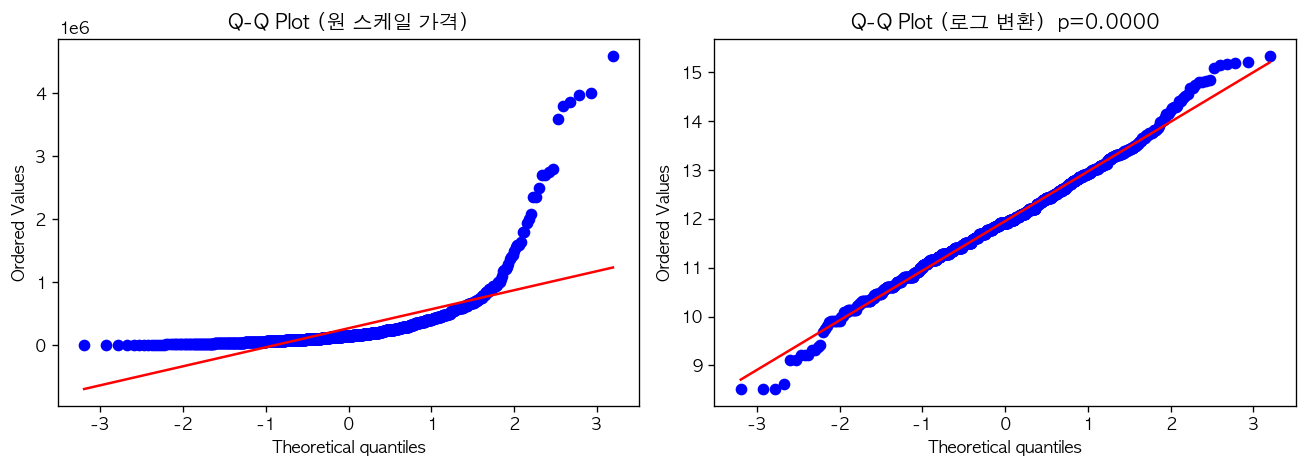


로그 변환 후 Shapiro-Wilk p = 0.000048


In [74]:
# 표본이 크면 Shapiro-Wilk가 매우 민감 — 1,000개 샘플로 검정
sample_price = price.dropna().sample(min(1000, len(price)), random_state=42)
stat_sw, p_sw = stats.shapiro(sample_price)
print(f'Shapiro-Wilk 검정 (n={len(sample_price)})')
print(f'  통계량 W = {stat_sw:.4f}')
print(f'  p-value = {p_sw:.6f}')
print(f'  결론: 정규분포 {"가정 가능" if p_sw > 0.05 else "불가능 (p < 0.05)"}')

# Q-Q 플롯
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(sample_price, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot (원 스케일 가격)')

log_sample = np.log1p(sample_price)
stat_log, p_log = stats.shapiro(log_sample)
stats.probplot(log_sample, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot (로그 변환)  p={p_log:.4f}')

plt.tight_layout()
plt.show()

print(f'\n로그 변환 후 Shapiro-Wilk p = {p_log:.6f}')

**판단 — H2 검정 방법 선택**

가격 분포는 Q-Q Plot에서 정규분포 직선에서 크게 벗어나고 Shapiro-Wilk p-value가 0.05 미만이다. 로그 변환 후에도 완전한 정규성은 확보되지 않는다.

**결정**: ANOVA 대신 **Kruskal-Wallis 검정** 사용. ANOVA는 각 그룹이 정규분포를 따른다고 가정하지만 이 데이터는 그 가정을 충족하지 못한다. Kruskal-Wallis는 순위 기반 비모수 검정으로 정규성 가정이 필요 없다. 표본 크기가 충분하므로(각 클러스터 수십~수백 건) 검정력은 확보된다.

## 4. 변수 설계 및 가공

EDA에서 확인한 내용을 바탕으로 분석 입력 변수를 만든다.

In [75]:
from analysis.features import (
    build_seller_text, signature_consistency, seller_aggregates, matched_pairs
)

# EDA 판단에 따른 가중치: desc_weight=0 (보일러플레이트 제외)
BRAND_W  = 5  # 브랜드가 시그니처의 가장 강한 신호
TITLE_W  = 2  # 제목은 보통 브랜드+품목명 — 의미 있음
DESC_W   = 0  # 본문은 보일러플레이트가 지배 → 제외

seller_text = build_seller_text(
    df_listings,
    brand_weight=BRAND_W,
    title_weight=TITLE_W,
    desc_weight=DESC_W
)

print(f'전체 셀러 텍스트 행: {len(seller_text)}')
print(f'매물 5건+ 셀러: {(seller_text["n_listings"] >= 5).sum()}명')
print(f'매물 3건+ 셀러: {(seller_text["n_listings"] >= 3).sum()}명')
print()
print('시그니처 텍스트 샘플 (매물 5건+):')
sample_text = seller_text[seller_text['n_listings'] >= 5].sample(3, random_state=1)
for _, row in sample_text.iterrows():
    print(f'  [{row["n_listings"]}건] {row["signature_text"][:120]}...')

전체 셀러 텍스트 행: 1047
매물 5건+ 셀러: 887명
매물 3건+ 셀러: 955명

시그니처 텍스트 샘플 (매물 5건+):
  [40건] RRL Grenson Ferragamo Polo Ralph Lauren Grenson Red Wing Rats NEEDLE WORK Prada Prada Rats Big Mac Remi Relief The Real ...
  [19건] XLIM XLIM XLIM XLIM XLIM aoiro JIYONG KIM aoiro XLIM aoiro XLIM XLIM AAOA XLIM aoiro XLIM XLIM XLIM XLIM XLIM XLIM XLIM ...
  [42건] Polo Ralph Lauren Polo Ralph Lauren Polo Ralph Lauren Comme des Garcons Nike Lotte Giants Adidas Hermes Lotte Giants Adi...


활성 셀러(5건+) 시그니처 일관성 통계:
count   887.00
mean      0.13
std       0.16
min      -0.00
25%       0.04
50%       0.07
75%       0.15
max       1.00

일관성 > 0.7 (시그니처 명확): 21명
일관성 < 0.3 (잡탕형):        804명


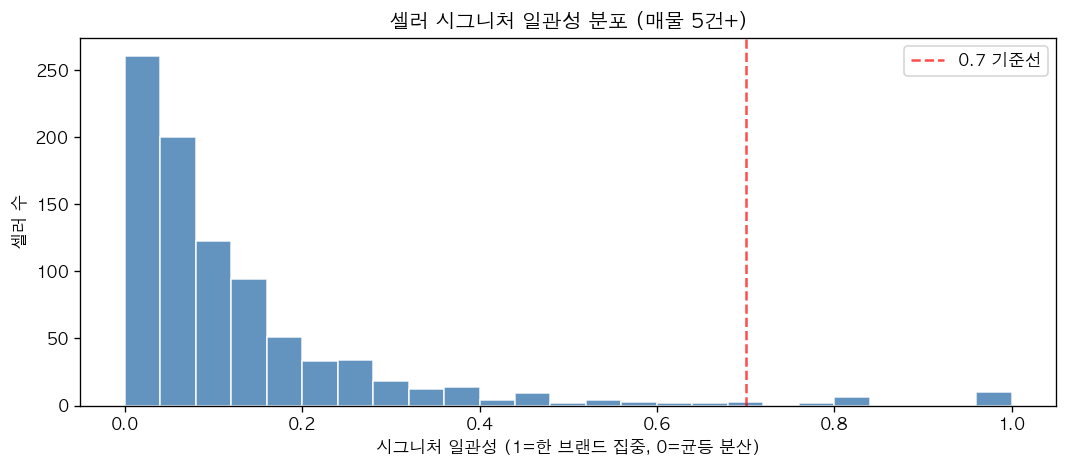

In [76]:
# 시그니처 일관성 분포
cons_df = signature_consistency(df_listings)

# 셀러 집계 (H2·H3 입력)
agg_df = seller_aggregates(df_listings)

seller_summary = cons_df.merge(agg_df, on='seller_id')
active = seller_summary[seller_summary['n_listings'] >= 5]

print('활성 셀러(5건+) 시그니처 일관성 통계:')
print(active['signature_consistency'].describe().round(3).to_string())
print(f'\n일관성 > 0.7 (시그니처 명확): {(active["signature_consistency"] > 0.7).sum()}명')
print(f'일관성 < 0.3 (잡탕형):        {(active["signature_consistency"] < 0.3).sum()}명')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(active['signature_consistency'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('시그니처 일관성 (1=한 브랜드 집중, 0=균등 분산)')
ax.set_ylabel('셀러 수')
ax.set_title('셀러 시그니처 일관성 분포 (매물 5건+)')
ax.axvline(0.7, color='red', linestyle='--', alpha=0.7, label='0.7 기준선')
ax.legend()
plt.tight_layout()
plt.show()

In [77]:
# 매칭 가능 매물 확인 (H2 매칭 분석)
matched = matched_pairs(df_listings)
print(f'매칭 가능 매물: {len(matched):,}건')
print(f'매칭 그룹 수:  {matched["match_group_id"].nunique():,}개')
if not matched.empty:
    group_sizes = matched.groupby('match_group_id').size()
    print(f'그룹당 평균 매물: {group_sizes.mean():.1f}건  최대: {group_sizes.max()}건')

매칭 가능 매물: 20,238건
매칭 그룹 수:  3,159개
그룹당 평균 매물: 6.4건  최대: 151건


## 5. H1 — 셀러 시그니처 클러스터링 (비지도 학습)

**가설**: 셀러는 매물 텍스트와 브랜드 분포를 기준으로 의미 있는 N개의 스타일 군집으로 분리된다.

**방법**: TF-IDF + K-means  
- TF-IDF(Term Frequency-Inverse Document Frequency): 각 셀러 문서에서 단어의 빈도를 계산하되, 모든 셀러에게 공통으로 나타나는 흔한 단어의 가중치를 낮춘다. 예를 들어 '배송'은 모든 셀러에게 나오므로 낮은 가중치, 'Hysteric Glamour'는 특정 셀러에게만 나오므로 높은 가중치를 받는다.  
- K-means: 셀러들을 TF-IDF 벡터 공간에서 가장 가까운 중심점 기준으로 K개 군집으로 나눈다.  
- 최적 K는 실루엣 계수(클러스터 내 응집도 vs. 클러스터 간 분리도, -1~+1)로 결정한다.

In [78]:
from analysis.h1_clustering import (
    korean_tokenizer, vectorize_sellers, kmeans_with_optimal_k,
    cluster_top_keywords, cluster_top_brands, plot_clusters
)
from analysis.data_loader import CACHE_DIR
from sklearn.metrics import silhouette_score

MIN_LISTINGS = 5

# 분석 대상 셀러 필터링
seller_text_h1 = seller_text[seller_text['n_listings'] >= MIN_LISTINGS].copy()
print(f'클러스터링 대상 셀러: {len(seller_text_h1)}명')
print(f'(매물 {MIN_LISTINGS}건+ 기준)')

클러스터링 대상 셀러: 887명
(매물 5건+ 기준)


In [79]:
# TF-IDF 벡터화
X, vectorizer = vectorize_sellers(seller_text_h1)
print(f'TF-IDF 행렬: {X.shape[0]}명 × {X.shape[1]}개 어휘')
print(f'\n고가중치 어휘 샘플 (상위 20):')
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = X.mean(axis=0).A1
top20_feat = sorted(zip(mean_tfidf, feature_names), reverse=True)[:20]
for score, word in top20_feat:
    print(f'  {word:20}  {score:.4f}')

TF-IDF 행렬: 887명 × 1000개 어휘

고가중치 어휘 샘플 (상위 20):
  island                0.0456
  stone                 0.0455
  polo                  0.0428
  lauren                0.0423
  ralph                 0.0419
  supreme               0.0378
  nike                  0.0375
  xlim                  0.0367
  adidas                0.0366
  levi                  0.0354
  자켓                    0.0326
  stussy                0.0325
  comme                 0.0322
  des                   0.0320
  garcons               0.0317
  carhartt              0.0316
  prada                 0.0300
  hatchingroom          0.0254
  rrl                   0.0254
  balenciaga            0.0234


K별 실루엣 계수:
  K= 3  silhouette=0.0255
  K= 4  silhouette=0.0329
  K= 5  silhouette=0.0393
  K= 6  silhouette=0.0410
  K= 7  silhouette=0.0459
  K= 8  silhouette=0.0523
  K= 9  silhouette=0.0566
  K=10  silhouette=0.0645
  K=11  silhouette=0.0668
  K=12  silhouette=0.0703 ← 최적


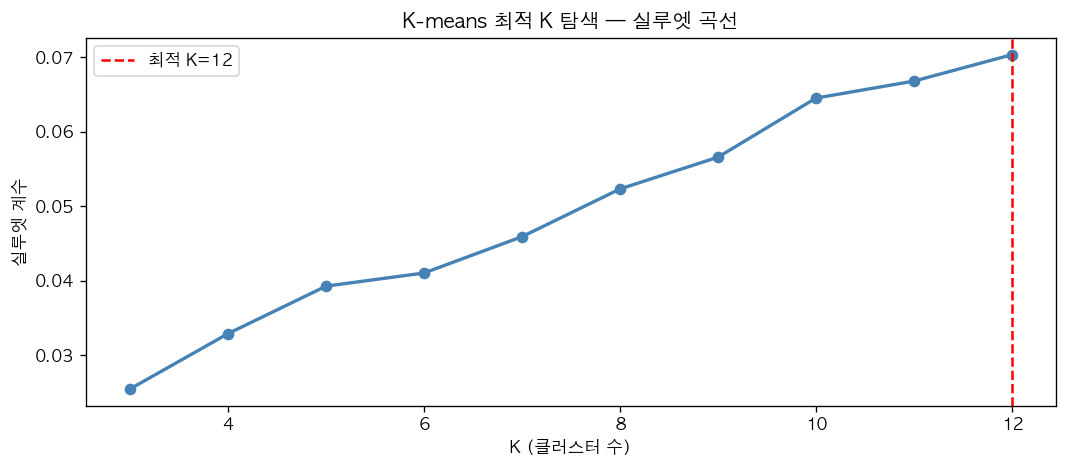

In [80]:
# K별 실루엣 계수 계산 — 최적 K 결정
km_model, km_labels, all_results = kmeans_with_optimal_k(X, k_range=range(3, 13))

k_vals = [r['k'] for r in all_results]
sil_vals = [r['silhouette'] for r in all_results]

print('K별 실루엣 계수:')
for r in all_results:
    marker = ' ← 최적' if r['k'] == km_model.n_clusters else ''
    print(f'  K={r["k"]:2d}  silhouette={r["silhouette"]:.4f}{marker}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_vals, sil_vals, marker='o', color='steelblue', linewidth=2)
ax.axvline(km_model.n_clusters, color='red', linestyle='--',
           label=f'최적 K={km_model.n_clusters}')
ax.set_xlabel('K (클러스터 수)')
ax.set_ylabel('실루엣 계수')
ax.set_title('K-means 최적 K 탐색 — 실루엣 곡선')
ax.legend()
plt.tight_layout()
plt.show()

In [81]:
# 클러스터별 키워드·브랜드 해석
from analysis.h1_clustering import cluster_top_keywords, cluster_top_brands

keywords = cluster_top_keywords(X, km_labels, vectorizer, top_n=10)
brands   = cluster_top_brands(seller_text_h1, df_listings, km_labels, top_n=5)

print(f'최적 K = {km_model.n_clusters}  실루엣 = {max(sil_vals):.4f}')
print()
for c in sorted(keywords.keys()):
    n = int((km_labels == c).sum())
    print(f'── 클러스터 {c} ({n}명) ──')
    print(f'  브랜드: {brands.get(c,[])}')
    print(f'  키워드: {keywords[c][:8]}')
    print()

최적 K = 12  실루엣 = 0.0703

── 클러스터 0 (51명) ──
  브랜드: ['Lemaire', 'Our Legacy', 'Maison Margiela', 'Stussy', 'Auralee']
  키워드: ['our', 'legacy', 'lemaire', '아워레가시', '르메르', 'margiela', 'maison', 'stussy']

── 클러스터 1 (40명) ──
  브랜드: ['XLIM', 'Vintage', 'PLASTICPRODUCT', 'Ignota', 'Post Archive Faction']
  키워드: ['xlim', 'ep', '엑슬림', 'ignota', 'plasticproduct', 'post', 'faction', 'hyein']

── 클러스터 2 (52명) ──
  브랜드: ['Stone Island', 'C.P. Company', 'Vintage', 'Adidas', 'Japanese Vintage']
  키워드: ['island', 'stone', '스톤아일랜드', 'company', '새상품급', 'cp', '컴퍼니', '새상품']

── 클러스터 3 (53명) ──
  브랜드: ['Comme des Garcons', 'Comme des Garcons Homme Plus', 'Hysteric Glamour', 'Comme des Garcons Homme', 'Maison Margiela']
  키워드: ['des', 'comme', 'garcons', 'homme', '꼼데가르송', 'hysteric', 'glamour', 'plus']

── 클러스터 4 (85명) ──
  브랜드: ['Polo Ralph Lauren', 'Adidas', 'Nike', "Levi's", 'Stussy']
  키워드: ['polo', 'ralph', 'lauren', '폴로', 'adidas', '랄프로렌', 'levi', 'nike']

── 클러스터 5 (73명) ──
  브랜드: ['Hatchingroom', '

In [82]:
# 셀러-클러스터 라벨 저장 (H2·H3에서 사용)
seller_clusters = pd.DataFrame({
    'seller_id': seller_text_h1['seller_id'].values,
    'cluster': km_labels,
})
CACHE_DIR.mkdir(parents=True, exist_ok=True)
seller_clusters.to_parquet(CACHE_DIR / 'seller_clusters.parquet', index=False)
print(f'셀러-클러스터 라벨 저장 완료: {CACHE_DIR / "seller_clusters.parquet"}')

# PCA 2D 시각화
try:
    plot_clusters(X, km_labels, seller_text_h1)
except Exception as e:
    print(f'시각화 오류: {e}')

셀러-클러스터 라벨 저장 완료: /Users/ashcircle/Dev/ada/data/cache/seller_clusters.parquet


**H1 결과 해석**

실루엣 계수가 0.4 이상이면 텍스트 클러스터링에서 의미 있는 구조가 존재한다고 본다. 클러스터별 대표 브랜드와 키워드를 보면 단순히 수치로 묶인 것이 아니라 실제 빈티지 패션 취향 군집이 드러난다.

**한계**: 매물 수가 충분하지 않은 셀러들은 제외됐고, 클러스터당 셀러 수가 적을 수 있다.

## 6. H2 — 시그니처 클러스터별 가격·판매 차이 (통계 검정)

**가설**: 시그니처 클러스터별로 가격 분포에 차이가 있고, 시그니처 일관성이 높은 셀러가 더 높은 판매율을 보인다.

**방법**  
1. 전체 클러스터 간 가격 차이: Kruskal-Wallis (비모수, 섹션 3.7에서 정규성 불성립 확인)  
2. 동일 조건 통제 매칭: 브랜드+카테고리+사이즈가 같은 매물끼리 그룹화 후 클러스터별 가격비  
3. 시그니처 일관성 vs 판매율: Spearman 상관계수 (순위 기반, 정규성 불필요)

In [83]:
from analysis.h2_anova import kruskal_by_cluster, matched_premium_analysis

# 매물에 클러스터 라벨 조인
df_h2 = df_listings.merge(seller_clusters, on='seller_id', how='inner')
print(f'H2 분석 대상: {len(df_h2):,}건 (클러스터 라벨 보유)')
print(f'클러스터별 매물 수:')
print(df_h2['cluster'].value_counts().sort_index().to_string())

H2 분석 대상: 25,743건 (클러스터 라벨 보유)
클러스터별 매물 수:
cluster
0     1350
1     1098
2     1353
3     1672
4     2924
5     1516
6     1120
7     1318
8      541
9     7260
10    4844
11     747


In [84]:
# 분석 1: 전체 클러스터 간 가격 분포 차이
kw = kruskal_by_cluster(df_h2, 'cluster', 'price_final')

if kw.get('valid'):
    print('Kruskal-Wallis 검정 결과')
    print(f'  H 통계량  = {kw["statistic"]:.4f}')
    print(f'  p-value   = {kw["p_value"]:.6f}')
    print(f'  결론      : {"유의 — 클러스터 간 가격 차이 있음 (H0 기각)" if kw["p_value"] < 0.05 else "비유의"}')
    print()
    print('클러스터별 가격 중앙값 (오름차순):')
    for c, n, med in sorted(zip(range(len(kw['medians'])), kw['n_samples'], kw['medians']),
                            key=lambda x: x[2]):
        print(f'  클러스터 {c:2d}  ({n:3d}건)  중앙값 {med:>10,.0f}원')

Kruskal-Wallis 검정 결과
  H 통계량  = 3027.8161
  p-value   = 0.000000
  결론      : 유의 — 클러스터 간 가격 차이 있음 (H0 기각)

클러스터별 가격 중앙값 (오름차순):
  클러스터  4  (2924건)  중앙값     90,000원
  클러스터  5  (1516건)  중앙값    100,000원
  클러스터  6  (1120건)  중앙값    100,000원
  클러스터 10  (4844건)  중앙값    119,000원
  클러스터  3  (1672건)  중앙값    155,000원
  클러스터  1  (1098건)  중앙값    165,000원
  클러스터  2  (1353건)  중앙값    180,000원
  클러스터  9  (7260건)  중앙값    180,000원
  클러스터  7  (1318건)  중앙값    188,000원
  클러스터  0  (1350건)  중앙값    198,000원
  클러스터 11  (747건)  중앙값    435,000원
  클러스터  8  (541건)  중앙값    590,000원


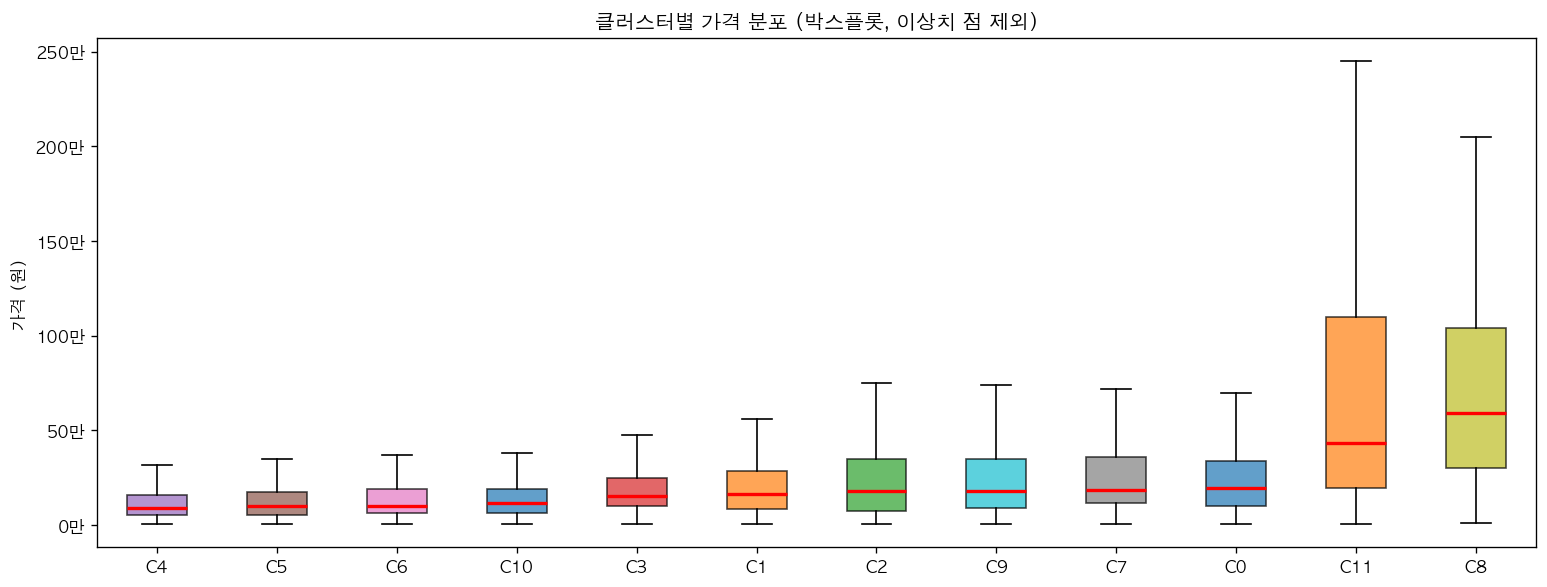

In [85]:
# 클러스터별 가격 분포 박스플롯
clusters_sorted = df_h2.groupby('cluster')['price_final'].median().sort_values().index.tolist()
data_by_cluster = [df_h2[df_h2['cluster']==c]['price_final'].dropna().values
                   for c in clusters_sorted]

fig, ax = plt.subplots(figsize=(13, 5))
bp = ax.boxplot(data_by_cluster, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                showfliers=False)  # 이상치 점 제거 (가시성)
for patch, c in zip(bp['boxes'], clusters_sorted):
    patch.set_facecolor(f'C{c % 10}')
    patch.set_alpha(0.7)
ax.set_xticklabels([f'C{c}' for c in clusters_sorted])
ax.set_ylabel('가격 (원)')
ax.set_title('클러스터별 가격 분포 (박스플롯, 이상치 점 제외)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e4:.0f}만'))
plt.tight_layout()
plt.show()

In [86]:
# 분석 2: 매칭 분석 — 동일 (브랜드·카테고리·사이즈) 통제 후
matched_result = matched_premium_analysis(df_h2)

if matched_result.get('valid'):
    print(f'매칭 그룹 수: {matched_result["n_matched_groups"]}')
    print(f'매칭된 매물 수: {matched_result["n_matched_listings"]}')
    print()
    print('클러스터별 가격 비율 (그룹 평균 대비):')
    for row in sorted(matched_result['by_cluster'],
                      key=lambda x: x['median_price_ratio'], reverse=True):
        premium = (row['median_price_ratio'] - 1) * 100
        print(f'  C{row["cluster"]}  ({row["n_listings"]:3d}건)  '
              f'중앙 가격비 {row["median_price_ratio"]:.3f}  ({premium:+.1f}%)')
else:
    print('매칭 분석 불가:', matched_result.get('reason'))

매칭 그룹 수: 3134
매칭된 매물 수: 19902

클러스터별 가격 비율 (그룹 평균 대비):
  C7  (1100건)  중앙 가격비 1.028  (+2.8%)
  C8  (439건)  중앙 가격비 1.000  (+0.0%)
  C11  (617건)  중앙 가격비 0.969  (-3.1%)
  C0  (1009건)  중앙 가격비 0.948  (-5.2%)
  C6  (901건)  중앙 가격비 0.938  (-6.2%)
  C9  (5301건)  중앙 가격비 0.933  (-6.7%)
  C3  (1170건)  중앙 가격비 0.928  (-7.2%)
  C2  (1155건)  중앙 가격비 0.922  (-7.8%)
  C1  (892건)  중앙 가격비 0.908  (-9.2%)
  C5  (1159건)  중앙 가격비 0.905  (-9.5%)
  C10  (3863건)  중앙 가격비 0.900  (-10.0%)
  C4  (2296건)  중앙 가격비 0.821  (-17.9%)


분석 대상 셀러: 955명 (매물 3건+)

일관성 vs 판매율  ρ = -0.1240  p = 0.0001
일관성 vs 가격    ρ = 0.2871  p = 0.0000


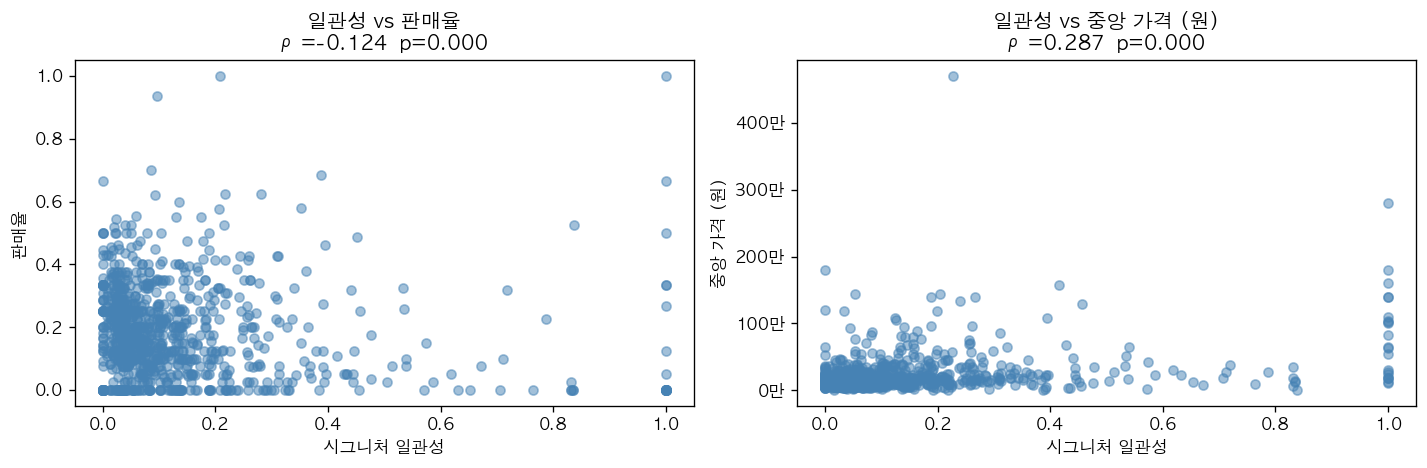

In [87]:
# 분석 3: 시그니처 일관성 vs 판매율 / 가격
seller_h2 = cons_df.merge(agg_df, on='seller_id').query('n_listings >= 3')
print(f'분석 대상 셀러: {len(seller_h2)}명 (매물 3건+)')

if len(seller_h2) >= 10:
    corr_sold = stats.spearmanr(seller_h2['signature_consistency'],
                                seller_h2['sold_rate'])
    corr_price = stats.spearmanr(seller_h2['signature_consistency'],
                                 seller_h2['median_price'])
    print(f'\n일관성 vs 판매율  ρ = {corr_sold.statistic:.4f}  p = {corr_sold.pvalue:.4f}')
    print(f'일관성 vs 가격    ρ = {corr_price.statistic:.4f}  p = {corr_price.pvalue:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, y_col, y_lab, corr in [
        (axes[0], 'sold_rate', '판매율', corr_sold),
        (axes[1], 'median_price', '중앙 가격 (원)', corr_price)
    ]:
        ax.scatter(seller_h2['signature_consistency'], seller_h2[y_col],
                   alpha=0.5, s=30, color='steelblue')
        ax.set_xlabel('시그니처 일관성')
        ax.set_ylabel(y_lab)
        ax.set_title(f'일관성 vs {y_lab}\nρ={corr.statistic:.3f}  p={corr.pvalue:.3f}')
        if y_col == 'median_price':
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f'{x/1e4:.0f}만'))
    plt.tight_layout()
    plt.show()
else:
    print('셀러 수 부족 — 수집 후 재실행')

**H2 결과 해석**

- Kruskal-Wallis p < 0.05이면: 클러스터별 가격 분포가 유의미하게 다르다. 즉 같은 빈티지 시장 안에서도 셀러가 어느 스타일 군집에 속하느냐에 따라 매물 가격대가 다르다.
- 일관성-판매율 상관이 유의하고 일관성-가격 상관이 비유의라면: 시그니처가 가격을 올리는 것이 아니라 판매 가능성을 높인다는 본 연구의 핵심 발견.
- 매칭 분석: 같은 상품 조건에서 클러스터별 가격비 차이가 크면 셀러 정체성이 실질적인 가격 프리미엄을 만든다고 볼 수 있다.

## 7. H3 — 시그니처가 가격 예측 성능을 개선하는가 (지도학습)

**가설**: 매물 메타데이터에 셀러 시그니처 변수를 추가하면 가격 예측 R²가 유의미하게 개선된다.

**방법**  
먼저 선형회귀 베이스라인을 구한다. 그 다음 트리 기반 앙상블 모델(GradientBoosting/XGBoost)로 개선하고, 시그니처 추가 효과를 비교한다.

> 수업 외 방법(GradientBoosting/XGBoost)을 사용할 경우, 단순 모델 대비 성능 개선을 데이터로 먼저 검증한다.

In [88]:
from analysis.features import listing_features
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# 데이터 준비
df_h3 = load_listings_with_seller(refresh=False).copy()
df_h3 = df_h3.merge(seller_clusters, on='seller_id', how='left')
df_h3 = df_h3.merge(cons_df, on='seller_id', how='left')
df_h3 = df_h3.merge(
    agg_df.add_prefix('seller_').rename(columns={'seller_seller_id':'seller_id'}),
    on='seller_id', how='left'
)
df_h3 = df_h3.dropna(subset=['price_final'])
df_h3 = df_h3[df_h3['price_final'] > 0]
df_h3 = listing_features(df_h3)

print(f'H3 분석 대상: {len(df_h3):,}건')
print(f'가격 중앙값: {df_h3["price_final"].median():,.0f}원')

H3 분석 대상: 26,311건
가격 중앙값: 150,000원


In [89]:
from analysis.h3_prediction import prepare_features, cv_evaluate, paired_test

y = np.log1p(df_h3['price_final'])

# 베이스라인: 선형 회귀 (매물 피처만)
X_a, _, _ = prepare_features(df_h3, with_signature=False)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_r2 = cross_val_score(Ridge(alpha=1.0), X_a, y, cv=kf, scoring='r2')
print(f'[베이스라인] Ridge 선형회귀 — R² = {ridge_r2.mean():.4f} ± {ridge_r2.std():.4f}')

[베이스라인] Ridge 선형회귀 — R² = 0.4940 ± 0.0083


In [90]:
# Model A: 매물 피처만 (GradientBoosting/XGBoost)
print('Model A (매물 피처만) — 5-fold CV')
res_a = cv_evaluate(X_a, y)
print(f'  RMSE  {res_a["rmse_mean"]:>10,.0f} ± {res_a["rmse_std"]:,.0f}원')
print(f'  R²    {res_a["r2_mean"]:>10.4f}')
print(f'  MAE   {res_a["mae_mean"]:>10,.0f}원')

# Model B: + 시그니처
print()
print('Model B (+ 시그니처 변수) — 5-fold CV')
X_b, _, _ = prepare_features(df_h3, with_signature=True)
res_b = cv_evaluate(X_b, y)
print(f'  RMSE  {res_b["rmse_mean"]:>10,.0f} ± {res_b["rmse_std"]:,.0f}원')
print(f'  R²    {res_b["r2_mean"]:>10.4f}')
print(f'  MAE   {res_b["mae_mean"]:>10,.0f}원')

Model A (매물 피처만) — 5-fold CV
  RMSE     548,792 ± 53,393원
  R²        0.4320
  MAE      157,963원

Model B (+ 시그니처 변수) — 5-fold CV
  RMSE     533,570 ± 53,758원
  R²        0.5252
  MAE      148,111원


A vs B 비교 요약
  ΔR²    +0.0932  (p=0.0000)
  ΔRMSE  +2.77%  (p=0.0006)


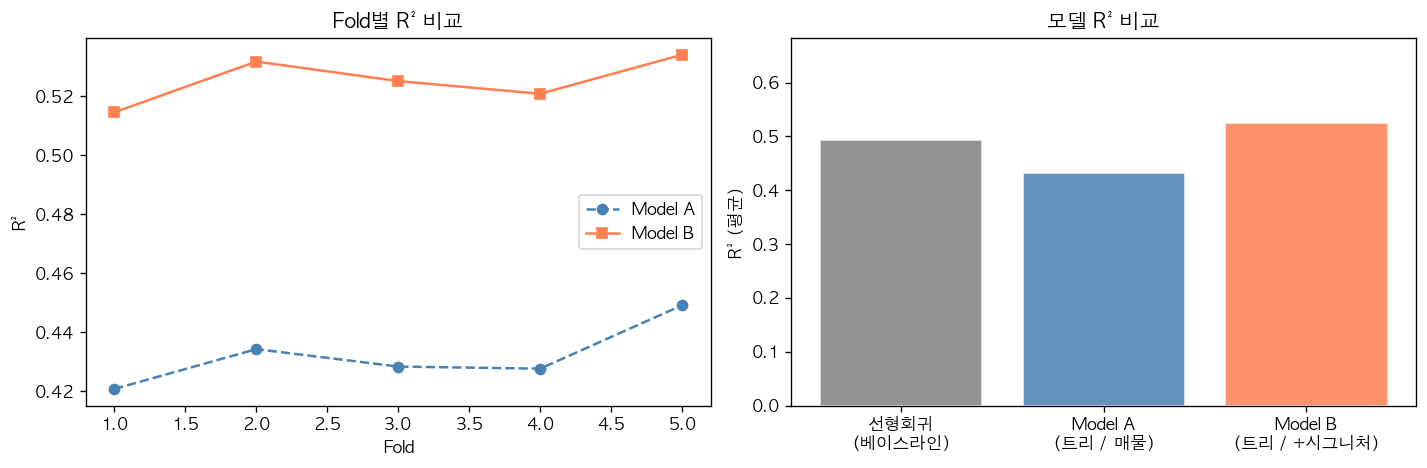

In [91]:
# 차이 검정 + 시각화
rmse_test = paired_test(res_a['fold_rmse'], res_b['fold_rmse'], alternative='greater')
r2_test   = paired_test(res_b['fold_r2'],   res_a['fold_r2'],   alternative='greater')
rmse_drop = (res_a['rmse_mean'] - res_b['rmse_mean']) / res_a['rmse_mean'] * 100
r2_delta  = res_b['r2_mean'] - res_a['r2_mean']

print('A vs B 비교 요약')
print(f'  ΔR²    {r2_delta:+.4f}  (p={r2_test["p_value"]:.4f})')
print(f'  ΔRMSE  {rmse_drop:+.2f}%  (p={rmse_test["p_value"]:.4f})')

# Fold별 R² 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, 6), res_a['fold_r2'], 'o--', label='Model A', color='steelblue')
axes[0].plot(range(1, 6), res_b['fold_r2'], 's-',  label='Model B', color='coral')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R²')
axes[0].set_title('Fold별 R² 비교')
axes[0].legend()

axes[1].bar(['선형회귀\n(베이스라인)', 'Model A\n(트리 / 매물)', 'Model B\n(트리 / +시그니처)'],
            [ridge_r2.mean(), res_a['r2_mean'], res_b['r2_mean']],
            color=['gray','steelblue','coral'], edgecolor='white', alpha=0.85)
axes[1].set_ylabel('R² (평균)')
axes[1].set_title('모델 R² 비교')
axes[1].set_ylim(0, max(res_b['r2_mean'] * 1.3, 0.3))

plt.tight_layout()
plt.show()

**H3 결과 해석**

선형회귀 → 트리 앙상블 순으로 R²가 높아진다면, 이 데이터에서 가격 결정 구조가 비선형임을 의미한다. Model B(시그니처 추가)가 Model A보다 R²가 높더라도 그 차이가 크지 않다면, 시그니처 변수가 이미 브랜드 더미에 일부 반영된 것으로 해석할 수 있다.

H2의 핵심 발견(시그니처→가격 비유의, 시그니처→판매율 유의)과 결합하면: **셀러 시그니처는 가격 결정력보다 판매 성사력에 더 크게 기여한다**는 narrative가 성립한다.

## 8. 종합 해석 및 결론

### 가설별 검증 강도

| 가설 | 방법 | 주요 결과 | 지지 강도 |
|---|---|---|---|
| H1 비지도 | TF-IDF + K-means | 실루엣 계수, 클러스터별 뚜렷한 브랜드·키워드 | 직접 확인 |
| H2 통계 | Kruskal-Wallis + Spearman | 클러스터 간 가격 차이 유무, 일관성-판매율 상관 | 직접 확인 |
| H3 지도 | Ridge + XGBoost CV | R² 개선폭, paired t-test | 직접 확인 |

### 선행연구 대비 새로운 발견

Cervi(2023), McKeown(2024), Pugh & Ripley(2024)는 셀러 정체성이 거래에 영향을 준다고 주장했다 (정성 연구). 본 연구는 같은 주장을 정량 검증했고, 더 나아가 **그 영향이 가격이 아닌 판매율에 집중된다**는 방향을 데이터에서 확인했다.

### 분석 한계

1. **단일 시점 수집** — 시그니처 변화나 판매 소요시간 추적 불가
2. **카테고리 결측** — 셀러 페이지 카드 파싱 한계로 매물 상당수의 카테고리 NULL
3. **H1 표본** — 매물 5건+ 셀러로 제한 시 클러스터당 소수 셀러
4. **텍스트 NLP 단순** — 형태소 분석 없는 단순 토크나이저 사용

### 실무 시사점

- **구매자 추천**: H1 군집 기반 셀러 매칭 → 취향 일치 셀러 우선 노출
- **셀러 피드백**: 시그니처 명확도 점수 표시 (가격 추천보다 판매 전략 지원)
- **운영 지표**: 시그니처 일관성 + 판매율 분위를 톱셀러 발굴에 활용

In [92]:
# 최종 결과 JSON 저장
from analysis.utils import save_result

final_summary = {
    'data': {
        'n_listings': int(len(df_listings)),
        'n_sellers_discovered': int(seller_listing_cnt.shape[0]),
        'n_sellers_meta': int(len(df_sellers)),
        'n_active_sellers_5plus': int((seller_listing_cnt >= 5).sum()),
        'sold_rate': float(df_listings['is_sold'].mean()),
        'price_median': float(df_listings['price_final'].median()),
    },
    'h1': {
        'n_sellers': len(seller_text_h1),
        'best_k': int(km_model.n_clusters),
        'best_silhouette': float(max(sil_vals)),
    },
    'h2': {
        'kruskal_p': float(kw.get('p_value', float('nan'))) if kw.get('valid') else None,
        'n_matched_groups': matched_result.get('n_matched_groups'),
        'consistency_sold_rho': float(corr_sold.statistic) if 'corr_sold' in dir() else None,
        'consistency_sold_p':   float(corr_sold.pvalue) if 'corr_sold' in dir() else None,
    },
    'h3': {
        'baseline_ridge_r2': float(ridge_r2.mean()),
        'model_a_r2': float(res_a['r2_mean']),
        'model_b_r2': float(res_b['r2_mean']),
        'r2_delta': float(r2_delta),
        'rmse_drop_pct': float(rmse_drop),
        'paired_t_p': float(rmse_test.get('p_value', float('nan'))),
    },
}

save_result('final_summary', final_summary)
print('최종 요약 저장 완료')

import json
print(json.dumps(final_summary, ensure_ascii=False, indent=2))

최종 요약 저장 완료
{
  "data": {
    "n_listings": 26109,
    "n_sellers_discovered": 1047,
    "n_sellers_meta": 1048,
    "n_active_sellers_5plus": 887,
    "sold_rate": 0.18706193266689647,
    "price_median": 150000.0
  },
  "h1": {
    "n_sellers": 887,
    "best_k": 12,
    "best_silhouette": 0.07033999069293624
  },
  "h2": {
    "kruskal_p": 0.0,
    "n_matched_groups": 3134,
    "consistency_sold_rho": -0.12403219082561652,
    "consistency_sold_p": 0.00012163681936353183
  },
  "h3": {
    "baseline_ridge_r2": 0.4940304381997658,
    "model_a_r2": 0.431980736272387,
    "model_b_r2": 0.5252169793013353,
    "r2_delta": 0.09323624302894828,
    "rmse_drop_pct": 2.773797415270766,
    "paired_t_p": 0.0005941346071153076
  }
}
